In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#dataset load krwane mai help karegi
from datasets import load_dataset

In [ ]:
emotion_dataset = load_dataset('dair-ai/emotion')
train_text = emotion_dataset['train']['text']
train_label = emotion_dataset['train']['label']
test_text = emotion_dataset['test']['text']
test_label = emotion_dataset['test']['label']

In [ ]:
label_names = emotion_dataset['train'].features['label'].names

In [ ]:
label_names

['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

In [ ]:
df_train = pd.DataFrame({
    'text':train_text,
    'label':[label_names[i] for i in train_label]
})

df_test = pd.DataFrame({
    'text':test_text,
    'label':[label_names[i] for i in test_label]
    })


In [ ]:
df_train.isnull().sum()

,0
text,0
label,0


<Axes: xlabel='label', ylabel='count'>

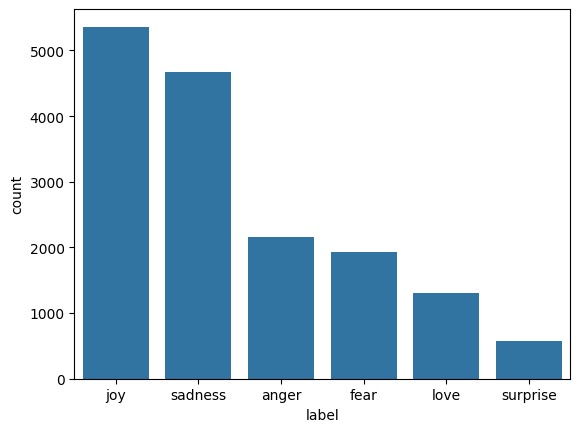

In [ ]:
sns.countplot(x=df_train['label'],order=df_train['label'].value_counts().index)


# Data Preprocessing - Using **NLP**

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
max_words = 10000

tokenizer = Tokenizer(num_words=max_words, oov_token='<unk>')
tokenizer.fit_on_texts(df_train['text'])

train_sequences = tokenizer.texts_to_sequences(df_train['text'])
test_sequences = tokenizer.texts_to_sequences(df_test['text'])

padded_train_sequences = pad_sequences(train_sequences, maxlen=50, padding='post', truncating='post')
padded_test_sequences = pad_sequences(test_sequences, maxlen=50, padding='post', truncating='post')

train_labels = np.array(train_label)
test_labels = np.array(test_label)
num_classes = len(label_names)
num_classes

print(f'Vocabulary size: {len(tokenizer.word_index)}')
print(f'Max Sentence Length: {padded_train_sequences.shape[1]}')


Vocabulary size: 15213
Max Sentence Length: 50


# Class Imbalance Handling- Class Weights

In [ ]:
from sklearn.utils import class_weight

class_weights = class_weight.compute_class_weight(
     class_weight='balanced',
     classes=np.unique(train_labels),
     y=train_labels
 )

class_weights_dict = dict(enumerate(class_weights))



In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
    )

# Phase 1 : Plain Foundation Model

Model 1 : Simple RNN

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN,Embedding,Dense,Dropout,LSTM,GRU

rnn_model = Sequential([
    Embedding(input_dim = max_words,output_dim=128,input_length=50),
    SimpleRNN(units=128,return_sequences=True),
    Dropout(0.5),
    SimpleRNN(units=64),
    Dropout(0.5),
    Dense(units=num_classes,activation='softmax')
])

rnn_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
rnn_model.fit(
    padded_train_sequences,
    train_labels,
    validation_data = (padded_test_sequences,test_labels),
    epochs=20,
    batch_size=32,
    class_weight=class_weights_dict,
    callbacks=[early_stopping]
)
rnn_loss, rnn_accuracy = rnn_model.evaluate(padded_test_sequences, test_labels)
print(f"RNN Loss: {rnn_loss}")
print(f"RNN Accuracy: {rnn_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.1552 - loss: 1.9463 - val_accuracy: 0.1375 - val_loss: 1.7914
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.1544 - loss: 1.8073 - val_accuracy: 0.1130 - val_loss: 1.7855
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.1471 - loss: 1.7855 - val_accuracy: 0.0895 - val_loss: 1.8025
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.1381 - loss: 1.7698 - val_accuracy: 0.0900 - val_loss: 1.7961
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.1463 - loss: 1.7633 - val_accuracy: 0.0695 - val_loss: 1.8149
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1130 - loss: 1.7855
RNN Loss: 1.7855114936828613
RNN Accuracy: 0.11299999803304672


In [ ]:
lstm_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128 , input_length = 50),
    LSTM(units=128, return_sequences=True),
    Dropout(0.5),
    LSTM(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax') #Output Layer
])

lstm_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

lstm_model.fit(
    padded_train_sequences,
    train_labels,
    validation_data=(padded_test_sequences, test_labels),
    epochs = 20,
    batch_size=32,
    class_weight=class_weights_dict,
    callbacks=[early_stopping]
)

lstm_loss, lstm_accuracy = lstm_model.evaluate(padded_test_sequences, test_labels)
print(f"LSTM Loss: {lstm_loss}")
print(f"LSTM Accuracy: {lstm_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.1584 - loss: 1.7947 - val_accuracy: 0.0330 - val_loss: 1.8270
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.1528 - loss: 1.7935 - val_accuracy: 0.1375 - val_loss: 1.7856
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.1559 - loss: 1.7943 - val_accuracy: 0.0340 - val_loss: 1.7988
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0330 - loss: 1.8270
LSTM Loss: 1.8269543647766113
LSTM Accuracy: 0.032999999821186066


In [ ]:
gru_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128 , input_length = 50),
    GRU(units=128, return_sequences=True),
    Dropout(0.5),
    GRU(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax') #Output Layer
])

gru_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

gru_model.fit(
    padded_train_sequences,
    train_labels,
    validation_data=(padded_test_sequences, test_labels),
    epochs = 20,
    batch_size=32,
    class_weight=class_weights_dict,
    callbacks=[early_stopping]
)

gru_loss, gru_accuracy = gru_model.evaluate(padded_test_sequences, test_labels)
print(f"gru Loss: {gru_loss}")
print(f"gru Accuracy: {gru_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.1549 - loss: 1.7969 - val_accuracy: 0.3480 - val_loss: 1.7792
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.1586 - loss: 1.7940 - val_accuracy: 0.2895 - val_loss: 1.7750
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.1566 - loss: 1.7944 - val_accuracy: 0.3460 - val_loss: 1.7858
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.1614 - loss: 1.7933 - val_accuracy: 0.0350 - val_loss: 1.8088
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.1575 - loss: 1.7918 - val_accuracy: 0.3420 - val_loss: 1.7870
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2895 - loss: 1.7750
gru Loss: 1.7750163078308105
gru Accuracy: 0.28949999809265137


In [ ]:
result_df = pd.DataFrame({
    'Model': ['RNN', 'LSTM', 'GRU'],
    'Loss': [rnn_loss, lstm_loss, gru_loss],
    'Accuracy': [rnn_accuracy, lstm_accuracy, gru_accuracy]
})

result_df.sort_values(by='Accuracy', ascending=False)


,Model,Loss,Accuracy
2,GRU,1.775016,0.2895
0,RNN,1.785511,0.1130
1,LSTM,1.826954,0.0330


# Phase 2 - Advanced Stacked Bidirectional GRU

In [ ]:
from tensorflow.keras.layers import Bidirectional

BiGRU = Sequential([
     Embedding(input_dim = max_words, output_dim = 300 , input_length = 50),
     Bidirectional(GRU(128,return_sequences=True)),
     Dropout(0.5),
     Bidirectional(GRU(64)),
     Dropout(0.5),
     Dense(units=num_classes, activation='softmax') #Output Layer
])

BiGRU.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

BiGRU.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_9 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
BiGRU.fit(
    padded_train_sequences,
    train_labels,
    validation_data=(padded_test_sequences, test_labels),
    epochs = 20,
    batch_size=32,
    class_weight=class_weights_dict,
    callbacks=[early_stopping]
)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.5728 - loss: 1.0567 - val_accuracy: 0.8980 - val_loss: 0.2951
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.9202 - loss: 0.2325 - val_accuracy: 0.9215 - val_loss: 0.2423
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.9467 - loss: 0.1446 - val_accuracy: 0.9205 - val_loss: 0.2605
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.9606 - loss: 0.1021 - val_accuracy: 0.9205 - val_loss: 0.2263
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.9728 - loss: 0.0763 - val_accuracy: 0.9195 - val_loss: 0.2835
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.9776 - loss: 0.0631 - val_accuracy: 0.9180 - val_loss: 0.2766
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.9795 - loss: 0.0575 - val_accuracy: 0.9240 - val_loss: 0.2603


In [ ]:
BiGRU_loss, BiGRU_accuracy = BiGRU.evaluate(padded_test_sequences, test_labels)
print(f"BiGRU Loss: {BiGRU_loss}")
print(f"BiGRU Accuracy: {BiGRU_accuracy}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9205 - loss: 0.2263
BiGRU Loss: 0.22631333768367767
BiGRU Accuracy: 0.9204999804496765


In [ ]:
Bi_lstm_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 300 , input_length = 50),
    Bidirectional(LSTM(units=128, return_sequences=True)),
    Dropout(0.5),
    Bidirectional(LSTM(units=64)),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax') #Output Layer
])
Bi_lstm_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
Bi_lstm_model.fit(
    padded_train_sequences,
    train_labels,
    validation_data=(padded_test_sequences, test_labels),
    epochs = 20,
    batch_size=32,
    class_weight=class_weights_dict,
    callbacks=[early_stopping]
)

BiLSTM_loss, BiLSTM_accuracy = Bi_lstm_model.evaluate(padded_test_sequences, test_labels)
print(f"BiLSTM Loss: {BiLSTM_loss}")
print(f"BiLSTM Accuracy: {BiLSTM_accuracy}")

Epoch 1/20


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


500/500 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.5800 - loss: 1.0494 - val_accuracy: 0.8780 - val_loss: 0.4075
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.9126 - loss: 0.2709 - val_accuracy: 0.8915 - val_loss: 0.3518
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.9364 - loss: 0.1835 - val_accuracy: 0.9115 - val_loss: 0.2901
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8780 - loss: 0.4075
BiLSTM Loss: 0.4075313210487366
BiLSTM Accuracy: 0.878000020980835


In [ ]:
result_bi_df = pd.DataFrame({
    'Model': ['BiGRU', 'BiLSTM'],
    'Loss': [BiGRU_loss, BiLSTM_loss],
    'Accuracy': [BiGRU_accuracy, BiLSTM_accuracy]
})

result_bi_df.sort_values(by='Accuracy', ascending=False)

,Model,Loss,Accuracy
0,BiGRU,0.226313,0.9205
1,BiLSTM,0.407531,0.8780


# Overall Evaluation and Bias Analysis

Final Model Confusion Matrix

63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step


<Axes: >

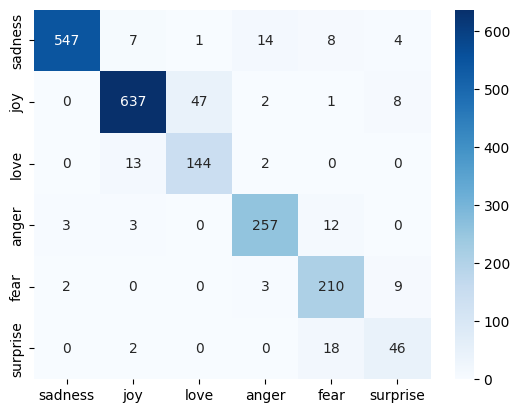

In [ ]:
from sklearn.metrics import confusion_matrix

BiGRU_predictions = np.argmax(BiGRU.predict(padded_test_sequences),axis=1)

sns.heatmap(confusion_matrix(test_label, BiGRU_predictions),annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)
#


# Final Predictions

In [ ]:
sample_texts = [
    "I can't believe how happy I am right now, this is amazing!",
    "I feel so alone and hopeless today.",
    "I am furious that they cancelled the trip at the last minute.",
    "I feel terrified when walking down dark alleyways alone.",
    "I was shocked and completely surprised by the unexpected gift!",
    "They did not give me a Bike."
]

sample_sequences = tokenizer.texts_to_sequences(sample_texts)
sample_padded_sequences = pad_sequences(sample_sequences, maxlen=50, padding='post', truncating='post')

sample_predictions = np.argmax(BiGRU.predict(sample_padded_sequences), axis=1)

for i in range(len(sample_texts)):
  print(f'Text: {sample_texts[i]}\nPredicted Emotion: {label_names[sample_predictions[i]]}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
Text: I can't believe how happy I am right now, this is amazing!
Predicted Emotion: joy
Text: I feel so alone and hopeless today.
Predicted Emotion: sadness
Text: I am furious that they cancelled the trip at the last minute.
Predicted Emotion: anger
Text: I feel terrified when walking down dark alleyways alone.
Predicted Emotion: fear
Text: I was shocked and completely surprised by the unexpected gift!
Predicted Emotion: surprise
Text: They did not give me a Bike.
Predicted Emotion: fear


# Save Model and Tokeniser

In [ ]:
import os
import pickle
model_dir = 'Aritfacts'
os.makedirs(model_dir,exist_ok=True)

BiGRU.save(os.path.join(model_dir,'BiGRU.keras'))
with open(os.path.join(model_dir,'tokenizer.pkl'),'wb') as f:
  pickle.dump(tokenizer,f)